In [ ]:
# Data-Driven Learning Difficulty Awareness & Screening Framework

 # Author: Palesa Sethibe

 # This project explores how academic performance patterns and contextual educational factors can support early awareness and screening for potential learning difficulties.

In [ ]:
#Loading the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Data Exploration and intial inspection

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
#Statistical Analysis
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
#Data cleaning

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
#Students in the lower Quartile(math)
math_25 = df["math score"].quantile(0.25)
df[df["math score"] <= math_25].head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
3,male,group A,associate's degree,free/reduced,none,47,57,44
7,male,group B,some college,free/reduced,none,40,43,39
9,female,group B,high school,free/reduced,none,38,60,50
11,male,group D,associate's degree,standard,none,40,52,43
14,female,group A,master's degree,standard,none,50,53,58


In [ ]:
#Students in the lower quartile(reading)
reading_25 = df["reading score"].quantile(0.25)
df[df["reading score"] <= reading_25].head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
3,male,group A,associate's degree,free/reduced,none,47,57,44
7,male,group B,some college,free/reduced,none,40,43,39
10,male,group C,associate's degree,standard,none,58,54,52
11,male,group D,associate's degree,standard,none,40,52,43
14,female,group A,master's degree,standard,none,50,53,58


In [ ]:
#The bottom 25%
low_reading = df[df["reading score"] <= reading_25]
low_reading.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
3,male,group A,associate's degree,free/reduced,none,47,57,44
7,male,group B,some college,free/reduced,none,40,43,39
10,male,group C,associate's degree,standard,none,58,54,52
11,male,group D,associate's degree,standard,none,40,52,43
14,female,group A,master's degree,standard,none,50,53,58


In [ ]:
low_reading["reading score"].describe()

,reading score
count,254.000000
mean,50.291339
std,7.982303
min,17.000000
25%,46.000000
50%,52.000000
75%,56.000000
max,59.000000


In [ ]:
#Lowest scores(sort by reading score)
df.sort_values(by="reading score").head(20)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10
327,male,group A,some college,free/reduced,none,28,23,19
596,male,group B,high school,free/reduced,none,30,24,15
980,female,group B,high school,free/reduced,none,8,24,23
76,male,group E,some high school,standard,none,30,26,22
211,male,group C,some college,free/reduced,none,35,28,27
896,male,group B,high school,free/reduced,none,36,29,27
601,female,group C,high school,standard,none,29,29,30
810,male,group A,some high school,standard,none,51,31,36
466,female,group D,associate's degree,free/reduced,none,26,31,38


In [ ]:
# Identifying Extreme Academic Performance Cases
df[df["math score"] == 0]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10


In [ ]:
# Building a Basic Screening Risk Calculator

In [ ]:
df["reading_difficulty"] = df["reading score"] < 60
df["math_difficulty"] = df["math score"] < 60
df["writing_difficulty"] = df["writing score"] < 60
df['reading_difficulty'].head()

# Scores below 60 were treated as indicators of possible academic difficulty based on common educational pass thresholds.

# These thresholds were used for screening purposes only and do not represent a formal diagnosis %%

,reading_difficulty
0,False
1,False
2,False
3,True
4,False


In [ ]:
df[["reading score", "reading_difficulty"]].head(10)

,reading score,reading_difficulty
0,72,False
1,90,False
2,95,False
3,57,True
4,78,False
5,83,False
6,95,False
7,43,True
8,64,False
9,60,False


In [ ]:
# Number of students with possible reading, writing and math difficulties

In [ ]:
df["reading_difficulty"].value_counts()

,count
reading_difficulty,
False,746
True,254


In [ ]:
df["math_difficulty"].value_counts()

,count
math_difficulty,
False,677
True,323


In [ ]:
df["writing_difficulty"].value_counts()

,count
writing_difficulty,
False,719
True,281


In [ ]:
df[["reading_difficulty", "math_difficulty", "writing_difficulty"]].apply(pd.Series.value_counts)

,reading_difficulty,math_difficulty,writing_difficulty
False,746,677,719
True,254,323,281


In [ ]:
#Adding contextual risk factors

In [ ]:
df["low_income"] = df["lunch"] == "free/reduced"

df["low_parent_edu"] = df["parental level of education"].isin([
    "some high school",
    "high school"
])

df["no_test_prep"] = df["test preparation course"] == "none"

In [ ]:
df[["reading score","writing score","math score" ,"low_income"]].head()

,reading score,writing score,math score,low_income
0,72,74,72,False
1,90,88,69,False
2,95,93,90,False
3,57,44,47,True
4,78,75,76,False


In [ ]:
df["low_income"].value_counts()

,count
low_income,
False,645
True,355


In [ ]:
#Assigning weights(without contextual risk factors)
df["risk_score_academic"] = (
    df["reading_difficulty"] * 3 +
    df["writing_difficulty"] * 2 +
    df["math_difficulty"] * 2
)

In [ ]:
#Assigning labels to the risk levels
df["risk_level_academic"] = "Low"
df.loc[df["risk_score_academic"] >= 2, "risk_level_academic"] = "Moderate"
df.loc[df["risk_score_academic"] >= 5, "risk_level_academic"] = "High"

In [ ]:
#See how many students in each risk level
#Risk distribution insight
df["risk_level_academic"].value_counts()

,count
risk_level_academic,
Low,603
High,247
Moderate,150


In [ ]:
#Convert the total to percentages(proportion)
df["risk_level_academic"].value_counts(normalize=True) * 100

,proportion
risk_level_academic,
Low,60.3
High,24.7
Moderate,15.0


In [ ]:
#Look at high risk students
df[df["risk_level_academic"] == "High"][[
    "math score", "reading score", "writing score"
]].head(10)

,math score,reading score,writing score
3,47,57,44
7,40,43,39
10,58,54,52
11,40,52,43
14,50,53,58
17,18,32,28
18,46,42,46
19,54,58,61
22,44,54,53
26,69,54,55


In [ ]:
#Average subject score per risk level
df.groupby("risk_level_academic")[[
    "math score", "reading score", "writing score"
]].mean()

,math score,reading score,writing score
risk_level_academic,,,
High,49.692308,50.105263,48.546559
Low,75.293532,77.897181,77.071310
Moderate,56.086667,65.473333,63.926667


In [ ]:
#Explore how risk is distributed across socioenomic groups

In [ ]:
#Analyse lunch status
pd.crosstab(df["lunch"], df["risk_level_academic"], normalize="index") * 100

risk_level_academic,High,Low,Moderate
lunch,,,
free/reduced,36.056338,43.661972,20.281690
standard,18.449612,69.457364,12.093023


In [ ]:
#Analyse test preparation
pd.crosstab(df["test preparation course"], df["risk_level_academic"], normalize="index") * 100

risk_level_academic,High,Low,Moderate
test preparation course,,,
completed,14.804469,71.787709,13.407821
none,30.218069,53.894081,15.887850


In [ ]:
#Analyse parental level of education
pd.crosstab(df["parental level of education"], df["risk_level_academic"], normalize="index") * 100

risk_level_academic,High,Low,Moderate
parental level of education,,,
associate's degree,22.072072,60.810811,17.117117
bachelor's degree,15.254237,71.186441,13.559322
high school,34.693878,51.020408,14.285714
master's degree,15.254237,69.491525,15.254237
some college,21.238938,63.716814,15.044248
some high school,30.726257,55.307263,13.966480


In [ ]:
#Building a screening tool
def calculate_risk(reading, writing, math):
    reading_difficulty = reading < 60
    writing_difficulty = writing < 60
    math_difficulty = math < 60

    risk_score = (
        reading_difficulty * 3 +
        writing_difficulty * 2 +
        math_difficulty * 2
    )

    if risk_score >= 5:
        risk_level = "High Risk"
    elif risk_score >= 2:
        risk_level = "Moderate Risk"
    else:
        risk_level = "Low Risk"

    return risk_score, risk_level

In [ ]:
calculate_risk(55, 70, 50)

(5, 'High Risk')

In [ ]:
score, level = calculate_risk(55, 70, 50)

print("Risk Score:", score)
print("Risk Level:", level)

Risk Score: 5
Risk Level: High Risk


In [ ]:
calculate_risk(70, 75, 80)   # should be Low
calculate_risk(58, 62, 55)   # Moderate
calculate_risk(40, 45, 50)   # High

(7, 'High Risk')

In [ ]:
# Enhanced Screening Prototype with Recommendations
def calculate_risk(reading, writing, math):

    reading_difficulty = reading < 60
    writing_difficulty = writing < 60
    math_difficulty = math < 60

    risk_score = (
        reading_difficulty * 3 +
        writing_difficulty * 2 +
        math_difficulty * 2
    )

    if risk_score >= 5:
        risk_level = "High"
        message = "Student may require immediate academic support."
    elif risk_score >= 2:
        risk_level = "Moderate"
        message = "Student may benefit from additional support."
    else:
        risk_level = "Low"
        message = "Student is performing within expected range."

    return risk_score, risk_level, message

In [ ]:
score, level, message = calculate_risk(55, 70, 50)

print("Risk Score:", score)
print("Risk Level:", level)
print("Recommendation:", message)

Risk Score: 5
Risk Level: High
Recommendation: Student may require immediate academic support.


In [ ]:
#Building a digital screening protoype that includes recommendation and disclaimer
def calculate_risk(reading, writing, math):

    reading_difficulty = reading < 60
    writing_difficulty = writing < 60
    math_difficulty = math < 60

    risk_score = (
        reading_difficulty * 3 +
        writing_difficulty * 2 +
        math_difficulty * 2
    )

    if risk_score >= 5:
        risk_level = "High"
        message = "Student may require immediate academic support."
    elif risk_score >= 2:
        risk_level = "Moderate"
        message = "Student may benefit from additional support."
    else:
        risk_level = "Low"
        message = "Student is performing within expected range."

    disclaimer = (
        "Disclaimer: This tool is for screening purposes only and does not "
        "provide a diagnosis. Further professional assessment may be required."
    )

    return risk_score, risk_level, message, disclaimer

In [ ]:
score, level, message, disclaimer = calculate_risk(55, 70, 50)

print("Risk Score:", score)
print("Risk Level:", level)
print("Recommendation:", message)
print(disclaimer)

Risk Score: 5
Risk Level: High
Recommendation: Student may require immediate academic support.
Disclaimer: This tool is for screening purposes only and does not provide a diagnosis. Further professional assessment may be required.


In [ ]:
#Creating a synthetic dataset
import pandas as pd
import random

data = []

for i in range(100):  # create 100 students

    reading = random.randint(30, 100)
    writing = random.randint(30, 100)
    math = random.randint(30, 100)

    score, level, message, _ = calculate_risk(reading, writing, math)

    data.append([
        i + 1,
        reading,
        writing,
        math,
        score,
        level,
        message
    ])

df_synthetic = pd.DataFrame(data, columns=[
    "student_id",
    "reading_score",
    "writing_score",
    "math_score",
    "risk_score",
    "risk_level",
    "recommendation"
])

df_synthetic.head()

,student_id,reading_score,writing_score,math_score,risk_score,risk_level,recommendation
0,1,52,71,32,5,High,Student may require immediate academic support.
1,2,40,76,84,3,Moderate,Student may benefit from additional support.
2,3,33,55,44,7,High,Student may require immediate academic support.
3,4,75,100,54,2,Moderate,Student may benefit from additional support.
4,5,34,31,69,5,High,Student may require immediate academic support.


In [ ]:
#Check how many students per risk level
df_synthetic["risk_level"].value_counts()

,count
risk_level,
Moderate,53
High,27
Low,20


In [ ]:
#SQL QUERIES

In [ ]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("screening.db")

df_synthetic.to_sql("screening_results", conn, index=False, if_exists="replace")

#Risk level  count
query = """
SELECT risk_level, COUNT(*) AS total_students
FROM screening_results
GROUP BY risk_level
"""

pd.read_sql(query, conn)

,risk_level,total_students
0,High,27
1,Low,20
2,Moderate,53


In [ ]:
#Risk level proportion
query = """
SELECT
    risk_level,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM screening_results), 1) AS percentage
FROM screening_results
GROUP BY risk_level
"""
pd.read_sql(query, conn)

,risk_level,percentage
0,High,27.0
1,Low,20.0
2,Moderate,53.0


In [ ]:
query = """
SELECT
    risk_level,
    COUNT(*) AS total_students,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM screening_results), 1) AS percentage
FROM screening_results
GROUP BY risk_level
"""
pd.read_sql(query, conn)

,risk_level,total_students,percentage
0,High,27,27.0
1,Low,20,20.0
2,Moderate,53,53.0


In [ ]:
#Average scores
query = """
SELECT
    risk_level,
    AVG(reading_score) AS avg_reading,
    AVG(writing_score) AS avg_writing,
    AVG(math_score) AS avg_math
FROM screening_results
GROUP BY risk_level
"""
pd.read_sql(query, conn)

,risk_level,avg_reading,avg_writing,avg_math
0,High,42.333333,55.740741,51.592593
1,Low,78.300000,80.400000,87.300000
2,Moderate,72.358491,62.264151,67.566038


In [ ]:
#Averages
query = """
SELECT
    risk_level,
    AVG(reading_score) AS avg_reading,
    AVG(writing_score) AS avg_writing,
    AVG(math_score) AS avg_math
FROM screening_results
GROUP BY risk_level
"""
pd.read_sql(query, conn)

,risk_level,avg_reading,avg_writing,avg_math
0,High,42.333333,55.740741,51.592593
1,Low,78.300000,80.400000,87.300000
2,Moderate,72.358491,62.264151,67.566038


In [ ]:
#Pattern 1
#Strong math, low reading & writing
query = """
SELECT *
FROM screening_results
WHERE
    math_score >= 70
    AND reading_score < 60
    AND writing_score < 60
    group by student_id
    order by math_score desc
"""
pd.read_sql(query, conn)

,student_id,reading_score,writing_score,math_score,risk_score,risk_level,recommendation
0,42,35,39,97,5,High,Student may require immediate academic support.
1,24,31,30,93,5,High,Student may require immediate academic support.
2,41,32,56,79,5,High,Student may require immediate academic support.


In [ ]:
#Pattern 2
#Math weak, reading & writing strong
query = """
SELECT *
FROM screening_results
WHERE
    math_score < 60
    AND reading_score >= 70
    AND writing_score >= 70
    group by student_id
    order by math_score
"""
pd.read_sql(query, conn)

,student_id,reading_score,writing_score,math_score,risk_score,risk_level,recommendation
0,27,95,84,34,2,Moderate,Student may benefit from additional support.
1,78,96,83,35,2,Moderate,Student may benefit from additional support.
2,87,77,77,35,2,Moderate,Student may benefit from additional support.
3,50,82,90,41,2,Moderate,Student may benefit from additional support.
4,36,91,99,42,2,Moderate,Student may benefit from additional support.
5,57,89,86,42,2,Moderate,Student may benefit from additional support.
6,56,79,93,52,2,Moderate,Student may benefit from additional support.
7,4,75,100,54,2,Moderate,Student may benefit from additional support.
8,94,90,73,54,2,Moderate,Student may benefit from additional support.


In [ ]:
#Pattern 3
#High risk, maths strong, reading and writing weak
query = """
SELECT *
FROM screening_results
WHERE
    risk_level = 'High'
    AND math_score >= 70
    AND reading_score < 60
    AND writing_score < 60
"""
pd.read_sql(query, conn)

,student_id,reading_score,writing_score,math_score,risk_score,risk_level,recommendation
0,24,31,30,93,5,High,Student may require immediate academic support.
1,41,32,56,79,5,High,Student may require immediate academic support.
2,42,35,39,97,5,High,Student may require immediate academic support.


In [ ]:
#High risk, math weak, reading and writing strong
query = """
SELECT *
FROM screening_results
WHERE
    risk_level = 'High'
    AND math_score < 60
    AND reading_score >= 70
    AND writing_score >= 70
"""
pd.read_sql(query, conn)

,student_id,reading_score,writing_score,math_score,risk_score,risk_level,recommendation


In [ ]:
#Visualisations

In [ ]:
risk_counts = df["risk_level_academic"].value_counts()

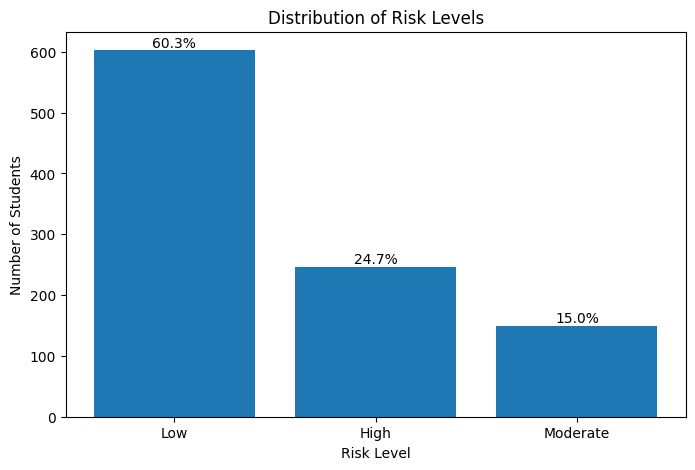

In [ ]:
#Distribution of risk levels
import matplotlib.pyplot as plt

risk_counts = df["risk_level_academic"].value_counts()
total = len(df)

plt.figure(figsize=(8,5))
bars = plt.bar(risk_counts.index, risk_counts.values)

plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")

# Add percentages on top
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{percentage:.1f}%",
             ha='center', va='bottom')

plt.show()

In [ ]:
difficulty_counts = [
    df["reading_difficulty"].sum(),
    df["writing_difficulty"].sum(),
    df["math_difficulty"].sum()
]

labels = ["Reading", "Writing", "Math"]

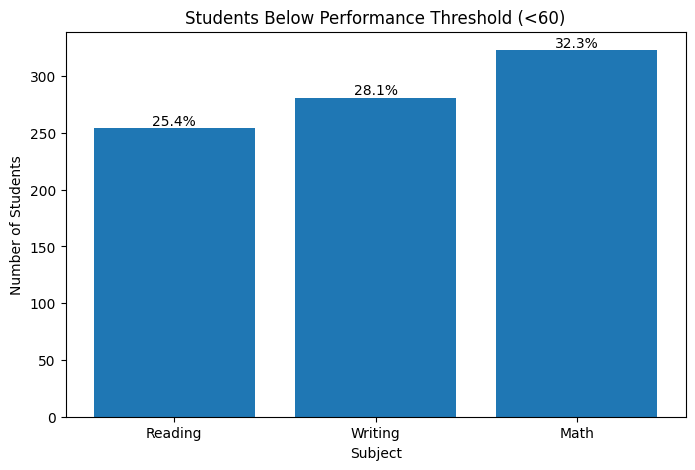

In [ ]:
import matplotlib.pyplot as plt

total = len(df)

plt.figure(figsize=(8,5))
bars = plt.bar(labels, difficulty_counts)

plt.title("Students Below Performance Threshold (<60)")
plt.xlabel("Subject")
plt.ylabel("Number of Students")

# Add percentages
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{percentage:.1f}%",
             ha='center', va='bottom')

plt.show()

In [ ]:
avg_scores = df.groupby("risk_level_academic")[[
    "reading score", "writing score", "math score"
]].mean()

avg_scores

,reading score,writing score,math score
risk_level_academic,,,
High,50.105263,48.546559,49.692308
Low,77.897181,77.071310,75.293532
Moderate,65.473333,63.926667,56.086667


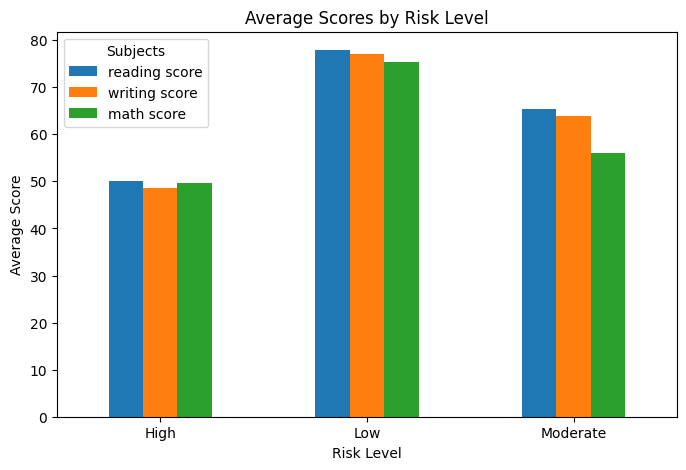

In [ ]:
import matplotlib.pyplot as plt

avg_scores.plot(kind="bar", figsize=(8,5))

plt.title("Average Scores by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Score")

plt.xticks(rotation=0)
plt.legend(title="Subjects")

plt.show()

In [ ]:
df["reading_difficulty"] = df["reading score"] < 60
df["writing_difficulty"] = df["writing score"] < 60
df["math_difficulty"] = df["math score"] < 60

In [ ]:
df["risk_score"] = (
    df["reading_difficulty"] * 3 +
    df["writing_difficulty"] * 2 +
    df["math_difficulty"] * 2
)

In [ ]:
df["risk_score"] = (
    df["reading_difficulty"] * 3 +
    df["writing_difficulty"] * 2 +
    df["math_difficulty"] * 2
)

In [ ]:
df["risk_level"] = "Low"
df.loc[df["risk_score"] >= 2, "risk_level"] = "Moderate"
df.loc[df["risk_score"] >= 5, "risk_level"] = "High"

In [ ]:
df["risk_level"].value_counts()

,count
risk_level,
Low,603
High,247
Moderate,150


<Axes: xlabel='lunch'>

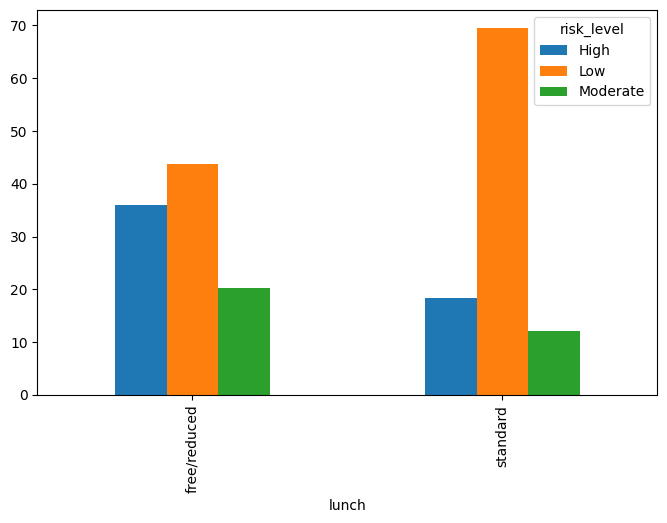

In [ ]:
lunch_risk = pd.crosstab(df["lunch"], df["risk_level"], normalize="index") * 100
lunch_risk.plot(kind="bar", figsize=(8,5))

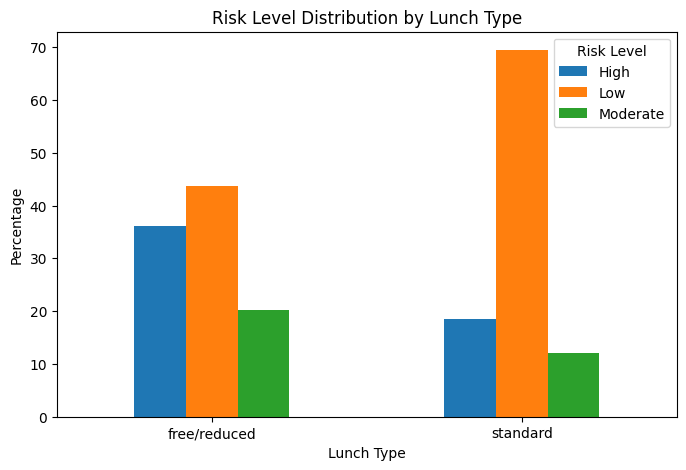

In [ ]:
import matplotlib.pyplot as plt

lunch_risk = pd.crosstab(df["lunch"], df["risk_level"], normalize="index") * 100

lunch_risk.plot(kind="bar", figsize=(8,5))

plt.title("Risk Level Distribution by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.legend(title="Risk Level")

plt.show()

In [ ]:
testprep_risk = pd.crosstab(df["test preparation course"], df["risk_level"], normalize="index") * 100

testprep_risk

risk_level,High,Low,Moderate
test preparation course,,,
completed,14.804469,71.787709,13.407821
none,30.218069,53.894081,15.887850


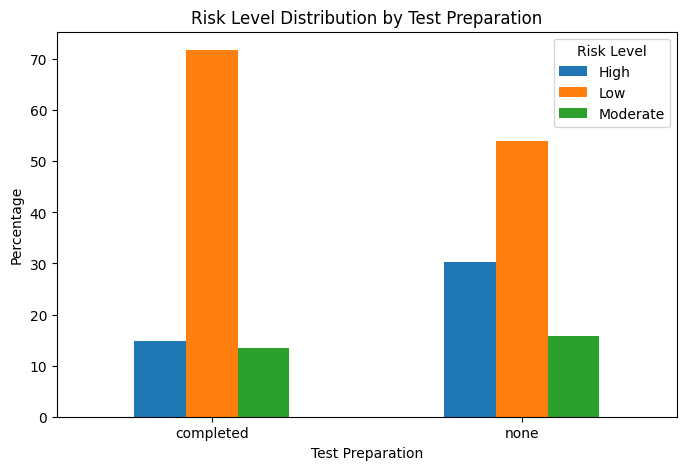

In [ ]:
import matplotlib.pyplot as plt

testprep_risk.plot(kind="bar", figsize=(8,5))

plt.title("Risk Level Distribution by Test Preparation")
plt.xlabel("Test Preparation")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.legend(title="Risk Level")

plt.show()

<Figure size 800x500 with 0 Axes>

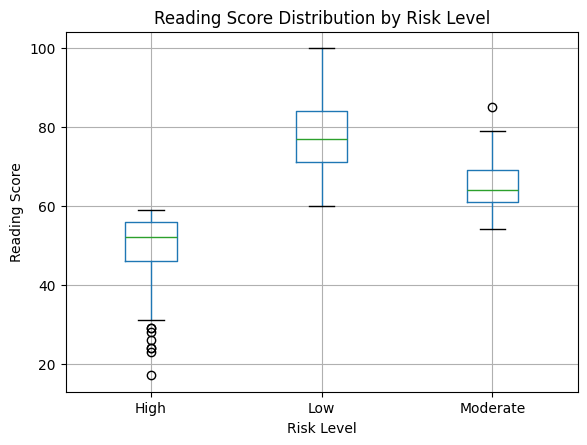

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(column="reading score", by="risk_level")

plt.title("Reading Score Distribution by Risk Level")
plt.suptitle("")  # removes default title
plt.xlabel("Risk Level")
plt.ylabel("Reading Score")

plt.show()

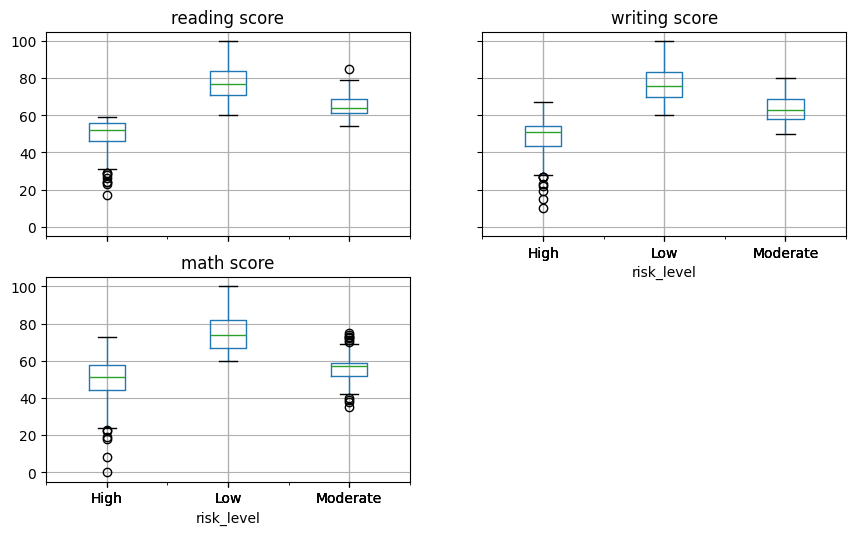

In [ ]:
df.boxplot(column=["reading score", "writing score", "math score"], by="risk_level", figsize=(10,6))

plt.suptitle("")
plt.title("Score Distribution by Risk Level")
plt.xlabel("Risk Level")
plt.show()

In [ ]:
## Limitations

## This project is intended for educational awareness and early screening purposes only.

## The dataset does not contain clinically diagnosed learning difficulties. Therefore, the framework identifies potential academic risk patterns rather than providing a medical or psychological diagnosis.

 ## Additional behavioural, cognitive and professional assessments would be required in real-world educational settings.